#How franchises actually build their squads

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Project_2/TATA-IPL-2025-Auction-Final-List-cleaned.xlsx')

In [3]:
df.head()

,full name,Country,State Association,National/International,Age,Age Group,2024 Team,C/U,Team,Type,Base,Sold,Category
0,Jos Buttler,England,International,International,34,30-35,RR,Capped,GT,BAT,2,15.75,Auctioned
1,Shreyas Iyer,India,MCA,National,30,30-35,KKR,Capped,PBKS,BAT,2,26.75,Auctioned
2,Rishabh Pant,India,DDCA,National,27,25-30,DC,Capped,LSG,BAT,2,27.00,Auctioned
3,Kagiso Rabada,South Africa,International,International,29,25-30,PBKS,Capped,GT,BOWL,2,10.75,Auctioned
4,Arshdeep Singh,India,PCA,National,26,25-30,PBKS,Capped,PBKS,BOWL,2,18.00,Auctioned


## 1. Spend & count share by Type per Team

In [30]:
type_mix = (df.groupby(['Team','Type'])
              .agg(total_spend=('Sold','sum'), count=('Sold','size'))
              .reset_index())
type_mix['spend_pct'] = type_mix['total_spend'] / type_mix.groupby('Team')['total_spend'].transform('sum') * 100
type_mix

,Team,Type,total_spend,count,spend_pct
0,CSK,AR,54.55,11,45.477282
1,CSK,BAT,32.80,7,27.344727
2,CSK,BOWL,32.60,7,27.177991
3,DC,AR,23.35,9,20.034320
4,DC,BAT,46.50,8,39.897040
5,DC,BOWL,46.70,6,40.068640
6,GT,AR,26.50,10,22.110972
7,GT,BAT,37.80,6,31.539424
8,GT,BOWL,55.55,9,46.349604
9,KKR,AR,54.15,6,50.162112


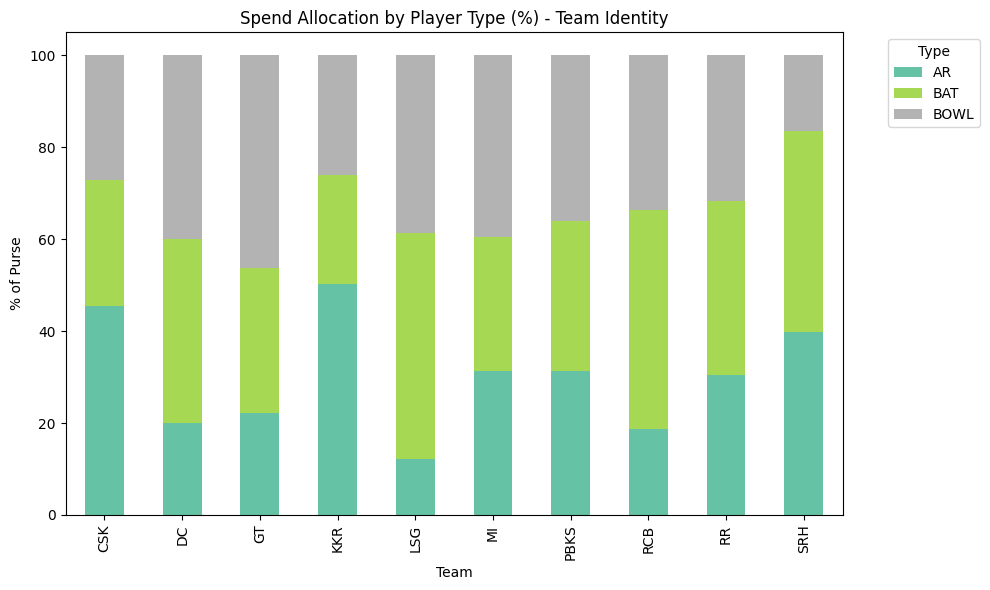

In [36]:
import matplotlib.pyplot as plt
# 1. Type mix (Bat/Bowl/AR) - 100% stacked bar
pivot1 = type_mix.pivot(index='Team', columns='Type', values='spend_pct')
pivot1.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Spend Allocation by Player Type (%) - Team Identity')
plt.ylabel('% of Purse')
plt.legend(title='Type', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

## 2. Overseas strategy

In [31]:
seas_mix = (df.groupby(['Team','National/International'])
              .agg(total_spend=('Sold','sum'), count=('Sold','size')).reset_index())
seas_mix['spend_pct'] = seas_mix['total_spend'] / seas_mix.groupby('Team')['total_spend'].transform('sum') * 100
seas_mix

,Team,National/International,total_spend,count,spend_pct
0,CSK,International,39.15,7,32.638599
1,CSK,National,80.80,18,67.361401
2,DC,International,40.50,7,34.749035
3,DC,National,76.05,16,65.250965
4,GT,International,52.25,7,43.596162
5,GT,National,67.60,18,56.403838
6,KKR,International,42.40,8,39.277443
7,KKR,National,65.55,13,60.722557
8,LSG,International,35.40,6,29.598662
9,LSG,National,84.20,17,70.401338


## 3. Retained vs Auctioned (core stability)

In [32]:
cat_mix = (df.groupby(['Team','Category'])
             .agg(total_spend=('Sold','sum'), count=('Sold','size')).reset_index())
cat_mix['spend_pct'] = cat_mix['total_spend'] / cat_mix.groupby('Team')['total_spend'].transform('sum') * 100
cat_mix

,Team,Category,total_spend,count,spend_pct
0,CSK,Auctioned,54.95,20,45.810754
1,CSK,Retained,65.00,5,54.189246
2,DC,Auctioned,72.80,19,62.462462
3,DC,Retained,43.75,4,37.537538
4,GT,Auctioned,68.85,20,57.446809
5,GT,Retained,51.00,5,42.553191
6,KKR,Auctioned,50.95,15,47.197777
7,KKR,Retained,57.00,6,52.802223
8,LSG,Auctioned,68.60,18,57.357860
9,LSG,Retained,51.00,5,42.642140


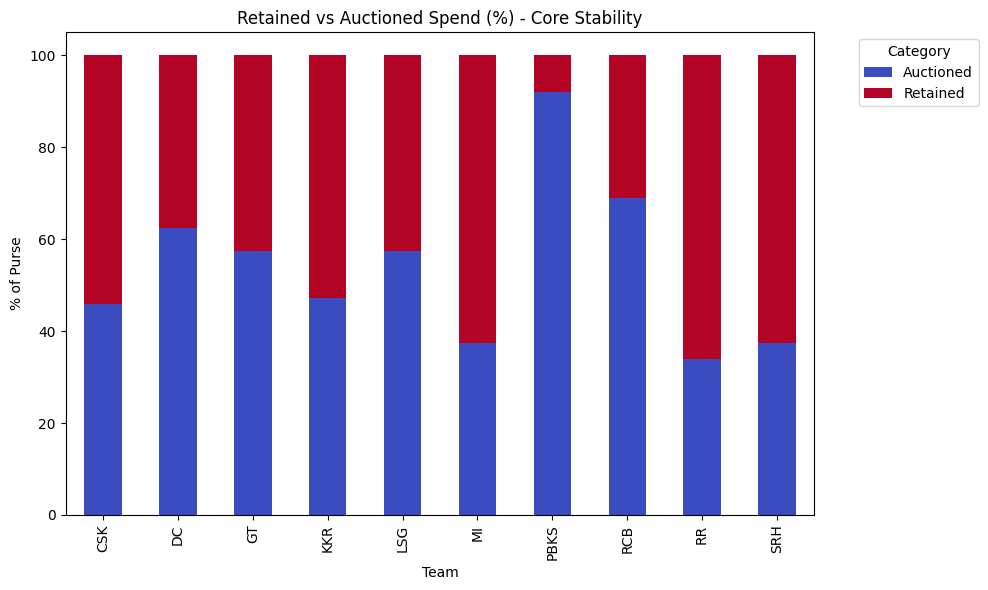

In [37]:
pivot2 = cat_mix.pivot(index='Team', columns='Category', values='spend_pct')
pivot2.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')
plt.title('Retained vs Auctioned Spend (%) - Core Stability')
plt.ylabel('% of Purse')
plt.legend(title='Category', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

## 4. Age strategy (youth vs experience bet)

In [33]:
age_mix = (df.groupby(['Team','Age Group'])
             .agg(total_spend=('Sold','sum'), count=('Sold','size')).reset_index())
age_mix['spend_pct'] = age_mix['total_spend'] / age_mix.groupby('Team')['total_spend'].transform('sum') * 100
age_mix

,Team,Age Group,total_spend,count,spend_pct
0,CSK,20-25,27.25,5,22.717799
1,CSK,25-30,34.00,9,28.345144
2,CSK,30-35,25.15,6,20.967070
3,CSK,Above 35,33.25,4,27.719883
4,CSK,Below 20,0.30,1,0.250104
5,DC,20-25,15.45,7,13.256113
6,DC,25-30,21.40,6,18.361218
7,DC,30-35,53.00,6,45.474045
8,DC,Above 35,26.70,4,22.908623
9,GT,20-25,12.15,5,10.137672


## 5. Star concentration — top 2 buys' share of team purse

In [35]:
def top2_share(g):
    total = g['Sold'].sum()
    top2 = g['Sold'].nlargest(2).sum()
    return pd.Series({'top2_spend': top2, 'team_total': total, 'top2_pct': top2/total*100})
star_conc = df.groupby('Team').apply(top2_share).reset_index()
star_conc

/tmp/ipykernel_1329/2668893376.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  star_conc = df.groupby('Team').apply(top2_share).reset_index()


,Team,top2_spend,team_total,top2_pct
0,CSK,36.00,119.95,30.012505
1,DC,30.50,116.55,26.169026
2,GT,34.50,119.85,28.785982
3,KKR,36.75,107.95,34.043539
4,LSG,48.00,119.60,40.133779
5,MI,34.35,119.80,28.672788
6,PBKS,44.75,119.65,37.400752
7,RCB,33.50,119.25,28.092243
8,RR,36.00,119.70,30.075188
9,SRH,41.00,119.80,34.223706


**Team-wise Recruitment Strategy Narratives**

**CSK** — All-rounder-led model: 45.5% of purse on all-rounders, only 5 retained players but they absorb 54.2% of spend — a small, expensive core surrounded by cheaper auction fill-ins. Balanced age spread, no clear youth or veteran bias.

**DC** — Rebuild mode: 62.5% of spend came via auction (only 4 retentions), bowling-heavy (40.1% spend) and skewed toward 30-35 age band (45.5% of spend) — buying ready-now bowling experience rather than building youth.

**GT** — Bowling-first, auction-built squad: 46.3% spend on bowlers, 57.4% via auction. Heavy bet on 25-30 age group (58.3% of spend) — peak-career batting/all-round talent, not high-risk youth.

**KKR** — All-rounder-anchored (50.2% spend, highest among all teams) with retention-heavy core (52.8% spend on just 6 retained players) and a tilt to 30-35 experience (43.9%) — title-defense, experience-over-youth strategy.

**LSG** — Batting-heavy (49.2% spend) built almost entirely through auction (57.4%), concentrated in 25-30 age group (55.7%) — also the most star-dependent squad: top 2 buys eat 40.1% of total purse, signalling reliance on a couple of marquee picks.

**MI** — Most retention-stable franchise: 62.6% of spend locked in just 5 retained players, lowest international spend share (22.8%) — domestic-core, bowling-tilted (39.6%) team betting on experienced (30-35 & Above-35 combine to 77.4%) talent, prioritizing continuity over auction gambles.

**PBKS** — Almost a fresh build: 92.1% of spend via auction (only 2 retained players, 7.9% spend) — by far the most auction-dependent franchise. Balanced Bat/Bowl/AR split (~32-36% each) but skewed to 30-35 experience (46.9%) and second-highest star concentration (37.4% on top 2 buys) — high-risk, high-reinvestment strategy.

**RCB** — Batting-first identity (47.6% spend, highest among all), majority via auction (69%), concentrated in 30-35 prime-batting years (44.9%) — clear strategy: buy proven middle-order/top-order bats at auction.

**RR** — Retention-core team (66% spend on 6 retained), lowest all-rounder count (4 players, smallest depth) but balanced age spread (~32-34% across 20-25/25-30/30-35) — a young, retained-core, less reliant on overseas (30.6%) strategy.

**SRH** — International-bowling/overseas-leaning team (50.4% spend — highest overseas share of any team), batting-led spend (43.7%) skewed to 30-35 group (58.1%, highest concentration in this band) — clear "experienced batting core + overseas firepower" model.

---

**Overall Insight (Executive Summary)**

Three distinct recruitment archetypes emerge across the league:

1. **Retention-anchored, continuity teams** — MI, RR, KKR — lock 53-66% of spend into a small retained core and lean on domestic/experienced talent. Lower volatility, lower star-concentration risk.
2. **Auction-rebuilt, star-dependent teams** — PBKS (92% auction), LSG (40% on top-2 buys), DC — high reinvestment, high dependency on 1-2 marquee signings, higher squad-building risk.
3. **Type-specialist teams** — CSK/KKR (all-rounder bet), GT/DC (bowling-first), RCB/SRH/LSG (batting-first) — each franchise has a clear positional identity rather than a balanced squad, suggesting deliberate role-specialization over generic "best player available" bidding.

Age strategy splits along similar lines: **MI, KKR, SRH, DC** bet on 30+ experience (>60% spend), while **GT, LSG** invest more in the 25-30 peak-emerging bracket — almost no franchise meaningfully invests in sub-20 talent (<3% spend league-wide), indicating IPL squad-building is overwhelmingly a "buy proven performers" market, not a development pipeline.